In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation

/tmp/ipykernel_23/735072267.py:8: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
/tmp/ipykernel_23/735072267.py:8: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation


In [2]:
#Functions
def score_histogram(df, column_name='score', title='Score Distribution of Train Dataset'):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=column_name, bins=5, kde=True, color='blue', edgecolor="black")
    mean_val = train_df[column_name].mean()
    median_val = train_df[column_name].median()
    plt.axvline(mean_val, color='red', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    plt.title(title)
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xlim(0, 5)
    plt.tight_layout()
    plt.show()
def prepare_dataset(df, column_name='score'):
    examples = []
    for row in df.itertuples():
        s1 = str(row.sentence1)
        s2 = str(row.sentence2)
        raw_score = float(row.score)
        normalized_score = raw_score / 5.0 #cosine similarity loss function of sentence transformers require labels [0;1]
        if s1 and s2: #when they are non-empty
            examples.append(InputExample(texts=[s1, s2], label=normalized_score)) #input format of sentence transformers
    return examples

 # 1. Data Preprocessing

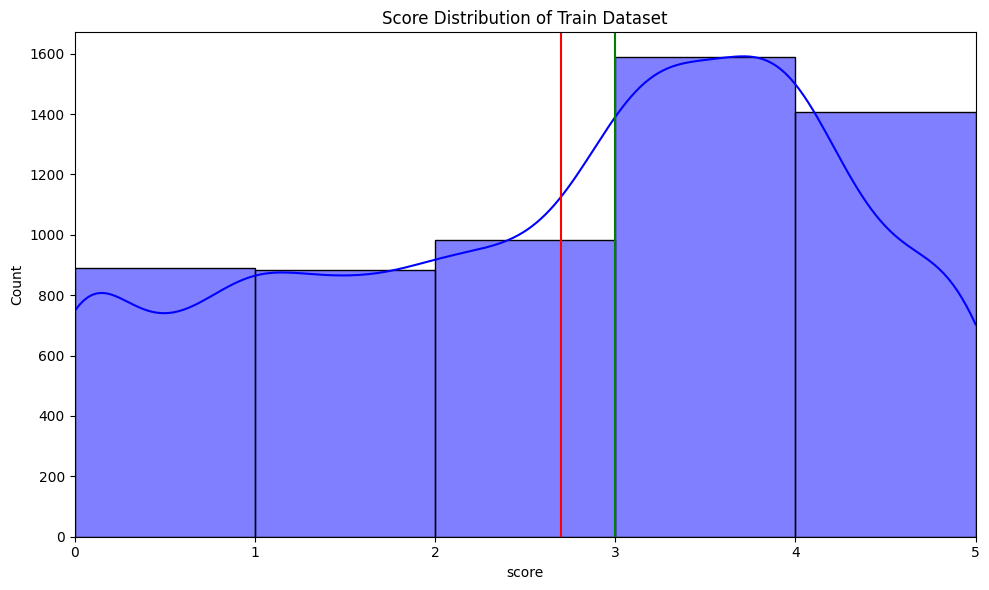

In [3]:
train_path =  "/kaggle/input/datasets/namtd07vn/text-sentiment-dataset/train.jsonl"
val_path = "/kaggle/input/datasets/namtd07vn/text-sentiment-dataset/validation.jsonl"
test_path = "/kaggle/input/datasets/namtd07vn/text-sentiment-dataset/test.jsonl"
train_df = pd.read_json(train_path, lines=True)
val_df = pd.read_json(val_path, lines=True)
test_df = pd.read_json(test_path, lines=True)
score_histogram(train_df)

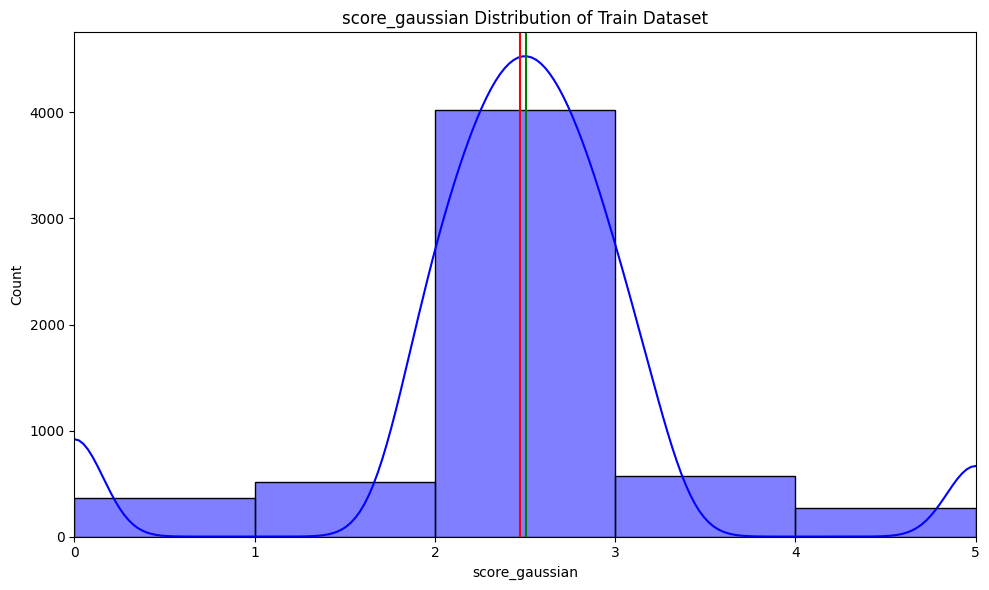

In [4]:
#Convert score distribution into Gaussian distribution
qt = QuantileTransformer(output_distribution='normal', random_state=42)
scores_reshaped = train_df['score'].values.reshape(-1, 1) #2D array
train_df['score_gaussian'] = qt.fit_transform(scores_reshaped)
min_val = train_df['score_gaussian'].min()
max_val = train_df['score_gaussian'].max()
train_df['score_gaussian'] = 5 * (train_df['score_gaussian'] - min_val) / (max_val - min_val) #min-max scaling to [0;5]
# plt.figure(figsize=(10, 6))
# sns.histplot(data=train_df, x="score_gaussian", bins=5, kde=True, color='blue', edgecolor="black")
# mean_score = train_df['score_gaussian'].mean()
# median_score = train_df['score_gaussian'].median()
# plt.axvline(mean_score, color='red', label=f'Mean: {mean_score:.2f}')
# plt.axvline(median_score, color='green', label=f'Mean: {median_score:.2f}')
# plt.title("score_gaussian Distribution of Train Dataset")
# plt.xlabel('score_gaussian')
# plt.ylabel('Count')
# plt.xlim(0, 5)
# plt.tight_layout()
# plt.show()
score_histogram(train_df, column_name='score_gaussian', title='score_gaussian Distribution of Train Dataset')

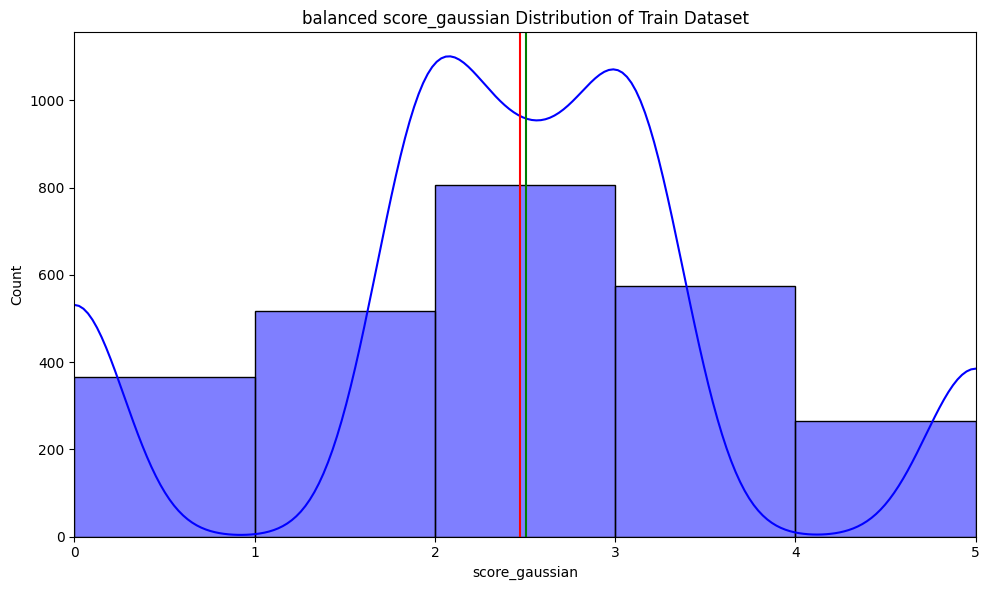

In [5]:
#Downsample gaussian_scores from 2 to 3 
df_thick = train_df[(train_df['score_gaussian'] >= 2) & (train_df['score_gaussian'] <= 3)]
df_thin = train_df[(train_df['score_gaussian'] < 2) | (train_df['score_gaussian'] > 3)]
df_thick_sampled = df_thick.sample(frac=0.2, random_state=42) #downsample to 25%
train_df_balanced = pd.concat([df_thin, df_thick_sampled]).reset_index(drop=True)
score_histogram(train_df_balanced, column_name='score_gaussian', title='balanced score_gaussian Distribution of Train Dataset')

**Even score distribution is not gaussian distribution, it is more balanced and ideal for model training**

In [6]:
train_samples = prepare_dataset(train_df_balanced, column_name='score_gaussian')
val_samples = prepare_dataset(val_df, column_name='score')
test_samples = prepare_dataset(test_df, column_name='score')
print(f'Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}')

Train: 2531, Val: 1500, Test: 1379


# 2. Model Training (all-MiniLM-L6-v2)

In [7]:
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=64) #steps/epoch = len(train_samples) / batch_size 
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)
train_loss = losses.CosineSimilarityLoss(model=model)
sentence1 = [example.texts[0] for example in val_samples]
sentence2 = [example.texts[1] for example in val_samples]
scores = [example.label for example in val_samples]
evaluator = evaluation.EmbeddingSimilarityEvaluator(sentence1, sentence2, scores, name='sts-val') #sts benchmark Dataset
num_epochs = 4
warmup_steps = int(len(train_dataloader) * num_epochs * 0.1) #Helps model avoid "gradient explosion" and steadily converge
output_path = '/kaggle/working/bi-encoder-all-MiniLM-L6-v2-sts'
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=num_epochs,
    evaluation_steps=100, 
    warmup_steps=warmup_steps,
    output_path=output_path,
    save_best_model=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Sts-val Pearson Cosine,Sts-val Spearman Cosine
20,No log,No log,0.877816,0.872310
40,No log,No log,0.881899,0.877289
60,No log,No log,0.884573,0.880756
80,No log,No log,0.884751,0.881204


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# 3. Model Evaluation 

In [8]:
best_model = SentenceTransformer(output_path)
train_loss = losses.CosineSimilarityLoss(model=model)
test_sentence1 = [example.texts[0] for example in test_samples]
test_sentence2 = [example.texts[1] for example in test_samples]
test_scores = [example.label for example in test_samples]
test_evaluator = evaluation.EmbeddingSimilarityEvaluator(test_sentence1, test_sentence2, test_scores, name='sts-test') #sts benchmark Dataset
test_results = test_evaluator(best_model, output_path=output_path)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [9]:
# print(list(test_results.keys()))
spearman_score = test_results['sts-test_spearman_cosine']
pearson_score = test_results['sts-test_pearson_cosine']
print(f'spearman_score: {spearman_score:.2f}')
print(f'pearson_score: {pearson_score:.2f}')

spearman_score: 0.84
pearson_score: 0.85


* **Model prediction is quite good**